# Inferência com modelos de Visão e Linguagem

Veremos como criar uma conversa com um VLM, e detalhes de como os dados são enviados e retornados pelo modelo.

\* Este notebook necessita de 3GB de memória de GPU para rodar.

In [ ]:
from transformers import Qwen3VLForConditionalGeneration, AutoProcessor, BitsAndBytesConfig

device = "cuda"

# O modelo Qwen3-VL utiliza patches de tamanho 16x16 pixels. Esses patches são agrupados em grupos
# de 2x2 patches, resultando em um tamanho de patch efetivo de 32x32 pixels. 
# A imagem será redimensionada de forma a possuir no máximo `max_pixels` pixels. Para uma imagem
# quadrada, o tamanho máximo da imagem será de 512x512 pixels
max_pixels = 256 * 32 * 32  

name = "Qwen/Qwen3-VL-2B-Instruct"

quantization_config = BitsAndBytesConfig(load_in_4bit=True)
model = Qwen3VLForConditionalGeneration.from_pretrained(
    name, 
    dtype="auto",
    device_map="auto",
    quantization_config=quantization_config,
    ) 
processor = AutoProcessor.from_pretrained(name, max_pixels=max_pixels)

In [2]:
# Template para o chat. Note a a presença do comando 
# "if content['type'] == 'image' ... <|vision_start|><|image_pad|><|vision_end|>"
# Esse comando substitui o tipo "image" por tokens que indicam a presença de uma imagem
print(processor.chat_template)

{%- if tools %}
    {{- '<|im_start|>system\n' }}
    {%- if messages[0].role == 'system' %}
        {%- if messages[0].content is string %}
            {{- messages[0].content }}
        {%- else %}
            {%- for content in messages[0].content %}
                {%- if 'text' in content %}
                    {{- content.text }}
                {%- endif %}
            {%- endfor %}
        {%- endif %}
        {{- '\n\n' }}
    {%- endif %}
    {{- "# Tools\n\nYou may call one or more functions to assist with the user query.\n\nYou are provided with function signatures within <tools></tools> XML tags:\n<tools>" }}
    {%- for tool in tools %}
        {{- "\n" }}
        {{- tool | tojson }}
    {%- endfor %}
    {{- "\n</tools>\n\nFor each function call, return a json object with function name and arguments within <tool_call></tool_call> XML tags:\n<tool_call>\n{\"name\": <function-name>, \"arguments\": <args-json-object>}\n</tool_call><|im_end|>\n" }}
{%- else %}
    {%- if me

In [3]:
messages = [
    {
        "role": "user",
        "content": [
            {
                "type": "image"  # Indica que uma imagem será inserida nesta posição
            },
            {
                "type": "text", 
                "text": "Describe this image."
            },
        ],
    }
]

text = processor.apply_chat_template(
    messages, tokenize=False, add_generation_prompt=True
)
text

'<|im_start|>user\n<|vision_start|><|image_pad|><|vision_end|>Describe this image.<|im_end|>\n<|im_start|>assistant\n'

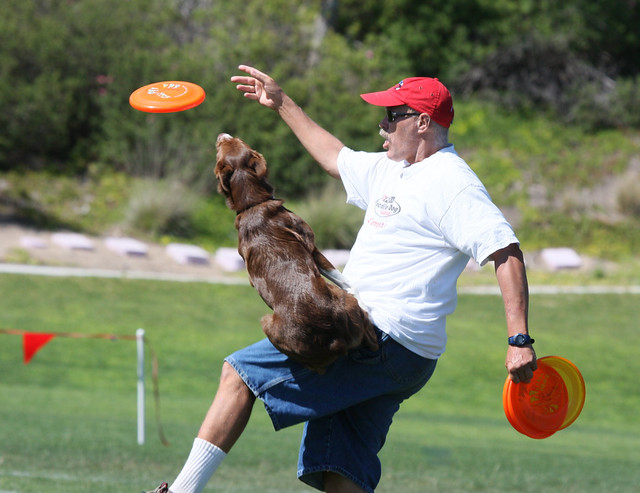

In [4]:
# Leitura da imagem
from PIL import Image
img = Image.open("../data/man_with_dog.jpg")
img

In [5]:
inputs = processor(
    text=text,
    images=img,
    videos=None,
    return_tensors="pt",
)

list(inputs.keys())

['input_ids',
 'attention_mask',
 'mm_token_type_ids',
 'pixel_values',
 'image_grid_thw']

Os elementos de `inputs` são:

1. input_ids: tokens representando o texto e imagem de entrada
2. pixel_values: a imagem de entrada do modelo, redimensionada e normalizada em relação à imagem original. Os pixels também são rearranjados de acordo com os patches criados
3. image_grid_thw: tupla indicando o número de patches gerados ao longo das linhas e colunas da imagem

In [6]:
inputs["input_ids"][0, :100]

tensor([151644,    872,    198, 151652, 151655, 151655, 151655, 151655, 151655,
        151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655,
        151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655,
        151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655,
        151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655,
        151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655,
        151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655,
        151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655,
        151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655,
        151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655,
        151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655,
        151655])

In [7]:
# Texto de entrada do modelo. num_patches/4 tokens <|image_pad|> são adicionados ao texto. 
# Esses tokens serão substituídos pelas representações dos patches da imagem gerados pelo 
# codificador de imagem ViT. O fator /4 é porque 2x2 tokens adjacentes são unidos por um MLP após 
# o modelo ViT
print(processor.batch_decode(inputs["input_ids"])[0])

<|im_start|>user
<|vision_start|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|ima

In [8]:
def get_img_shape(image_grid_thw, processor):
    """Tamanho da imagem que foi de fato processada pelo modelo."""
    
    grid_t, grid_h, grid_w = image_grid_thw
    ps = processor.image_processor.patch_size
    return grid_h.item()*ps, grid_w.item()*ps

input_shape = get_img_shape(inputs["image_grid_thw"][0], processor)
input_shape

(448, 576)

In [9]:
print(inputs["pixel_values"].shape)

# O tamanho de `pixel_values` é dado por (número de patches, tamanho de cada patch)
# O tamanho de cada patch é dado por (2 * número de canais * altura * largura / num_patches). Há
# um fator de 2 porque a imagem é replicada pois o modelo foi treinado recebendo sempre no mínimo
# 2 imagens (para processamento de vídeo).
num_patches = inputs["image_grid_thw"].prod()
tam_patches = 2*3*input_shape[0]*input_shape[1]//num_patches
(num_patches, tam_patches)

torch.Size([1008, 1536])


(tensor(1008), tensor(1536))

In [10]:
generated_ids = model.generate(**inputs.to(device), max_new_tokens=128)
num_input_tokens = len(inputs.input_ids[0])
output_text = processor.batch_decode(
   generated_ids[:, num_input_tokens:], skip_special_tokens=True
)
print(output_text)

['This is a photograph of a man and a dog in a grassy field, likely during a dog agility or frisbee competition. The man is in the foreground, and the dog is in mid-air, seemingly jumping or leaping to catch a frisbee. The man is wearing a white t-shirt, blue shorts, and a red cap, and is holding a frisbee in his left hand. The dog, a brown and white long-haired breed, is in the air, reaching for the orange frisbee. The man is also holding a frisbee in his right hand. The background is a green, grass']


### Conversa sobre a imagem

Os códigos acima estão implementados na classe Chat do arquivo chat_utils.py. A classe também possui o método `add_to_chat` que permite adicionar novas mensagens ao histórico de mensagens, incluindo a resposta do modelo.

In [11]:
from chat_utils import Chat

chat = Chat(model, processor)

img = Image.open("../data/man_with_dog.jpg")

output = chat.query_model("Is there a person in this image?", img)
output

'Yes, there is a person in this image. The person is a man wearing a white t-shirt, blue shorts, and a red hat, and he is holding a yellow frisbee in his right hand. He is also wearing sunglasses and has a dog on his left. The dog is jumping in the air, and the man is in the middle of a jump. The dog is on the left side of the man.'

In [12]:
chat.add_to_chat(output, role="assistant")

output = chat.query_model("What is the color of the person's shirt?")
print(output)

The person's shirt is white.


In [13]:
chat.add_to_chat(output, role="assistant")

output = chat.query_model("Where are they?")
print(output)

Based on the image, the person and the dog are on a grassy field. The field is located in the middle of a park. The person is standing on the grass, and the dog is jumping in the air. The dog is on the left side of the person. The person is holding a yellow frisbee in his right hand. The person is wearing a white t-shirt, blue shorts, and a red hat, and he is wearing sunglasses. The dog is jumping in the air. The person is in the middle of a jump. The dog is on the left side of the person. The person is standing on the
